### Classification of cellular states in GBM tumor-model pairs and generation of Figure 5b, 5c

This notebook provides an example for the analysis of GBM pairs shown in Fig. 5 and generates corresponding GBM panels for Figures 5b and 5c.

Setup user-defined parameters. Provide the full path to "HCMI_snRNAseq_data_metadata" as `Work_dir` and the full path to the current GitHub (parent) directory as `Code_dir`.

In [ ]:
cohort = "GBM"

Work_dir = "/groups/ac2248_gp/shares/hcmi/single-nuclei/HCMI_snRNAseq_data_metadata/" # parent directory for input data
Code_dir = "/groups/ac2248_gp/lz2841/ColumbiaProjects/HCMI-single-nuclei/" # path to GitHub folder

Other settings include the reference population for data centering and scaling and graphic parameters.

In [2]:
reference = "centroid" 

pval_NaRnEA = 0.15
binary_output = False

include_unknown_barplots = False

Paths to directory collecting markers and demultiplexed input data are specified below.

In [ ]:
filtering_level_vcf = "filtered_01" # "no_filtered": VCFs; "filtered": VCFs filtered at MAF>=1%, "filtered_01": VCFs filtered at MAF >=0.1%
sample_assignment = "best_gt_thresh" # "best_gt_thresh"; "sng1st_gt" 


# Postprocessing filtering_level_vcf
if filtering_level_vcf == "no_filtered":
    filtering_level_vcf = ""
elif filtering_level_vcf == "filtered":
    filtering_level_vcf = "-filtered"
elif filtering_level_vcf == "filtered_01":
    filtering_level_vcf = "-filtered-01"
else:
    print("Unknown value provided for filtering_level_vcf")

markers_dir = f"{Code_dir}markers/" # path to directory collecting gene expression markers

Specify cases in the cohort.

In [4]:
cases=["HCM-BROD-0416-C71", "HCM-BROD-0213-C71", "HCM-BROD-0028-C71", "HCM-BROD-0415-C71", "HCM-BROD-0199-C71", "HCM-BROD-0012-C71", "HCM-BROD-0002-C71"]

Import packages and custom functions.

In [ ]:
import sys
import scanpy as sc
import numpy as np 
from numpy import nanmedian, NaN
import pandas as pd
import os 
from matplotlib import rc_context
import seaborn as sns
import matplotlib.pyplot as plt
import pyviper
sc.settings.verbosity = 0
sc.logging.print_header()
sc.settings.set_figure_params(frameon=False, dpi=100, facecolor="white")
from matplotlib.backends.backend_pdf import PdfPages
import hdf5plugin
import argparse
import anndata
import gc
from contextlib import contextmanager
from prettytable import PrettyTable
from tabulate import tabulate
import warnings
warnings.simplefilter("ignore", category=UserWarning)
from scipy.sparse import issparse
import re
from matplotlib.colors import LinearSegmentedColormap
from itertools import compress
from scipy.stats import combine_pvalues
from openpyxl import Workbook
import math
from scipy.stats import chi2_contingency
sys.path.append(f'{Code_dir}funcs/')
from processing_funcs import *


import marsilea as ma
import marsilea.plotter as mp
from matplotlib.patches import Rectangle

# Custom function: retrieving putative malignant cells
def process_clusters(clusters_putative_malignant):
    # Extract the value from the Series (assuming a single element in the Series)
    cluster_value = clusters_putative_malignant.values[0]
    
    # Check if the value is "all"
    if isinstance(cluster_value, str) and cluster_value.lower() == "all":
        return cluster_value
    # If it's a comma-separated string, split it into a list of integers
    elif isinstance(cluster_value, str) and "," in cluster_value:
        return [int(i) for i in cluster_value.split(",")]
    # If it's a single integer, wrap it in a list
    else:
        return [int(cluster_value)]
    
# Specify other graphic parameters
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 7

scanpy==1.10.2 anndata==0.10.8 umap==0.5.6 numpy==1.24.3 scipy==1.12.0 pandas==2.2.2 scikit-learn==1.5.1 statsmodels==0.14.2 igraph==0.11.6 pynndescent==0.5.13


Load snRNA-seq metadata.

In [ ]:
snRNAseq_metadata_path = f"{Code_dir}Matched Model_Tumor for Sequencing.xlsx"
snRNAseq_metadata = pd.read_excel(snRNAseq_metadata_path, sheet_name="Samplesheet_for_Analysis")

Load snRNA-seq data and subset for putative malignant cells only

In [7]:
adata_samples = {}  # initialize dictionary collecting AnnData object
samples_metadata_path = f"{Work_dir}/metadata/" # path to gene expression metadata
for case in cases:

    print(f"Case: {case}")

    case_metadata = snRNAseq_metadata[snRNAseq_metadata["Case ID"] == case] # subset for the Case ID being analyzed
    # Automatically define sample names and paths to data

    samples = [f'{case_metadata.loc[idx,"Multiplex (GEM) ID"]}_{case}' for idx in case_metadata.index] # samples names
    file_paths = {ID: f"{Work_dir}demultiplexed_samples_{sample_assignment}{filtering_level_vcf}/{ID}_gt.h5ad" for ID in samples} # path to data

    # Load snRNA-seq metadata
    for sample, path in file_paths.items():
        # Load gene expression data and include it into AnnData object
        print('Loading ID',sample,end=' ')
        adata_samples[sample] = sc.read_h5ad(filename=path) # adata
        adata_samples[sample].var_names_make_unique()
        adata_samples[sample].obs["Sample Type"] = adata_samples[sample].obs["Sample Type"].str.rstrip() # strip spaces from Sample Type
        print(': AnnData of dimensions',adata_samples[sample].shape)
        # Subset for only the cells that previously passed QC and then only for putative malignant cells
        sample_metadata_path = f"{samples_metadata_path}{sample}-metadata.tsv"
        sample_infercnv_path = f"{samples_metadata_path}{sample}-chrs-infercnv.tsv"
        clusters_putative_malignant = case_metadata[case_metadata["Sample ID snRNAseq"] == sample]["Putative malignant clusters"]

        sample_metadata = pd.read_csv(sample_metadata_path, sep="\t")
        sample_infercnv = pd.read_csv(sample_infercnv_path, sep="\t")


        columns_to_add_metadata = sample_metadata.columns.difference(adata_samples[sample].obs.columns)
        sample_metadata = sample_metadata[columns_to_add_metadata]

        # subset for cells retained in the metadata table
        print("Subsetting only for putative tumor cells")

        cohort = list(case_metadata[case_metadata["Sample ID snRNAseq"] == sample]["Cohort"])[0]

        adata_samples[sample] = adata_samples[sample][adata_samples[sample].obs.index.isin(sample_metadata["barcode"])]
        adata_samples[sample].obs = adata_samples[sample].obs.merge(sample_metadata, left_on='barcode', right_on="barcode", how='left') # attach metadata
        # subset of only putative malignant cells
        clusters_putative_malignant = process_clusters(clusters_putative_malignant)
        if clusters_putative_malignant != "all":
            adata_samples[sample] = adata_samples[sample][adata_samples[sample].obs["clusters"].isin(clusters_putative_malignant)]

            if cohort == "PDAC":
                adata_samples[sample].obs.set_index("barcode", inplace=True) # set index
                adata_samples[sample] = adata_samples[sample][adata_samples[sample].obs["singler_BpE_cg"] == "Epithelial cells"]

        adata_samples[sample].obs.set_index("barcode", inplace=True) # set indewx
        sc.pp.calculate_qc_metrics(adata_samples[sample], qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

    # Gene selection
    gene_names = adata_samples[sample].var_names # assume gene names are the same across all samples
    gene_counts = np.zeros(len(gene_names))
    # Iterate over each sample and accumulate the counts
    for sample, adata in adata_samples.items():
        if issparse(adata.X):
            gene_counts += np.array(adata.X.sum(axis=0)).flatten()
        else:
            gene_counts += np.sum(adata.X, axis=0)
    # Convert to DataFrame for better readability
    gene_counts_df = pd.DataFrame(data=gene_counts, index=gene_names, columns=['Total_Counts'])
    genes_retain = gene_counts_df[gene_counts_df["Total_Counts"] >= 10].index.to_list() # genes to retain 
    genes_retain = [str(gene) for gene in genes_retain]

    del gene_names, gene_counts, gene_counts_df
    gc.collect()

Case: HCM-BROD-0416-C71
Loading ID AG006_HCM-BROD-0416-C71 : AnnData of dimensions (8267, 38606)
Subsetting only for putative tumor cells
Loading ID AG007_HCM-BROD-0416-C71 : AnnData of dimensions (6130, 38606)
Subsetting only for putative tumor cells
Case: HCM-BROD-0213-C71
Loading ID AG006_HCM-BROD-0213-C71 : AnnData of dimensions (3318, 38606)
Subsetting only for putative tumor cells
Loading ID AG007_HCM-BROD-0213-C71 : AnnData of dimensions (20737, 38606)
Subsetting only for putative tumor cells
Case: HCM-BROD-0028-C71
Loading ID AG004_HCM-BROD-0028-C71 : AnnData of dimensions (26785, 38606)
Subsetting only for putative tumor cells
Loading ID AG005_HCM-BROD-0028-C71 : AnnData of dimensions (16175, 38606)
Subsetting only for putative tumor cells
Case: HCM-BROD-0415-C71
Loading ID AA016_HCM-BROD-0415-C71 : AnnData of dimensions (10615, 38606)
Subsetting only for putative tumor cells
Loading ID AA017_HCM-BROD-0415-C71 : AnnData of dimensions (4453, 38606)
Subsetting only for putative 

Perform gene filtering and concatenate samples 

In [8]:
samples = list(adata_samples.keys())
for sample in samples:
    print(f"Gene filtering for {sample}")
    adata_samples[sample] = adata_samples[sample][:, genes_retain]

# Samples concatenation
adata_all = sc.concat(list(adata_samples.values()), axis = 0, join = 'outer') # integrate counts
adata_all.layers["counts"] = adata_all.X.copy()
adata_all.obs["Sample ID snRNAseq"] = pd.Categorical(adata_all.obs["Sample ID snRNAseq"], categories=samples, ordered=True) # order categories according to the samples list


del adata_samples
gc.collect()

Gene filtering for AG006_HCM-BROD-0416-C71
Gene filtering for AG007_HCM-BROD-0416-C71
Gene filtering for AG006_HCM-BROD-0213-C71
Gene filtering for AG007_HCM-BROD-0213-C71
Gene filtering for AG004_HCM-BROD-0028-C71
Gene filtering for AG005_HCM-BROD-0028-C71
Gene filtering for AA016_HCM-BROD-0415-C71
Gene filtering for AA017_HCM-BROD-0415-C71
Gene filtering for AA014_HCM-BROD-0199-C71
Gene filtering for AA015_HCM-BROD-0199-C71
Gene filtering for AA014_HCM-BROD-0012-C71
Gene filtering for AA015_HCM-BROD-0012-C71
Gene filtering for AA016_HCM-BROD-0002-C71
Gene filtering for AA017_HCM-BROD-0002-C71


32080

Data preprocessing: normalization, centering and scaling based on the reference signature.

In [9]:
# Data preprocessing 
print("Normalizing (data); log-transforming (logdata); and scaling the data (scale) for. Setting scaled data as the defaut 'X'")
sc.pp.normalize_total(adata_all, target_sum=1e4, inplace=True) # normalize data 
sc.pp.log1p(adata_all) # logdata - log-normalization
adata_all.layers["logdata"] = adata_all.X.copy() # store logdata in the corresponding layer  


# Retrieve tumor centroid
print("Loading centroid of malignant cells in tumors as the reference to center and scale the data.")
gene_reference = pd.read_csv(f"{Work_dir}GBM-malignant-reference-signature.tsv", sep="\t")
gene_reference = gene_reference.set_index("gene")  # Setting gene names as the index
gene_reference = gene_reference[gene_reference.index.isin(adata_all.var_names)]  # subset to match var_names
gene_reference = gene_reference.loc[adata_all.var_names]
gene_means = gene_reference['mean'].values
gene_stds = gene_reference['std'].values
gene_means = gene_means.reshape(1, -1)  # Reshape to (1, n_genes) to broadcast along the cell axis
gene_stds = gene_stds.reshape(1, -1)    # Reshape to (1, n_genes) for broadcasting


# Perform centering and scaling:
adata_all.layers["scaled_to_tumor_data"] = adata_all.layers["logdata"].copy()
adata_all.layers["scaled_to_tumor_data"] = (adata_all.layers["scaled_to_tumor_data"] - gene_means) / gene_stds
adata_all.layers["scaled_to_tumor_data"][adata_all.layers["scaled_to_tumor_data"] >= 10] = 10 # trim to 10 values that are above this value

print("Setting  'scale_to_tumor_data' as the default matrix. ")
adata_all.X = adata_all.layers["scaled_to_tumor_data"]
layer_enrichment = "scaled_to_tumor_data" # layer on which to perform the enrichment

Normalizing (data); log-transforming (logdata); and scaling the data (scale) for. Setting scaled data as the defaut 'X'
Loading centroid of malignant cells in tumors as the reference to center and scale the data.
Setting  'scale_to_tumor_data' as the default matrix. 


### Perform enrichment analysis and visualization

Load GBM gene sets from [Neftel et. al, 2019](https://www.cell.com/cell/fulltext/S0092-8674(19)30687-7?_returnURL=https%3A%2F%2Flinkinghub.elsevier.com%2Fretrieve%2Fpii%2FS0092867419306877%3Fshowall%3Dtrue).

In [ ]:
print(f"Performing pathway enrichment analysis for at the single-nucleus level")
# Suva' Lab markers
Suva_gene_sets = pd.read_excel(f"{markers_dir}GBM-markers.xlsx", sheet_name="S2_Neftel") 
Suva_gene_sets.drop(columns=['G1/S', 'G2/M'], inplace=True)
#Suva_gene_sets = Suva_gene_sets.rename(columns=lambda x: x + " subtype")
Suva_network = pd.melt(Suva_gene_sets, var_name='regulator', value_name='target').dropna(subset=['target'])
Suva_network["mor"] = 1
Suva_network["likelihood"] = 1
Suva_network = Suva_network.drop_duplicates(subset=['regulator', 'target'])
Suva_network = pyviper.Interactome('lineage_markers', Suva_network) # convet to interactome
Suva_network.net_table["regulator"] = Suva_network.net_table["regulator"].str.replace("-like","")

Performing pathway enrichment analysis for at the single-nucleus level


Compute the enrichment and collapse MES1, MES2 into MES and NPC1, NPC2 into NPC

In [11]:
# compute the enrichments
Suva_enr_nn = pyviper.tl.path_enr(adata_all, pathway_interactome=Suva_network, layer=layer_enrichment, enrichment="narnea", verbose="False", store_input_data=False)

# Combine the MES-like and NPC-like subtypes
MES = Suva_enr_nn[:, ['MES1', 'MES2']].X
NPC = Suva_enr_nn[:, ['NPC1', 'NPC2']].X
MES_like = MES.max(axis=1)
NPC_like = NPC.max(axis=1)

Suva_enr_nn.obs['MES'] = MES_like # add it as new var
Suva_enr_nn.obs['NPC'] = NPC_like # add it as new var

Removed 14 targets.
Preparing the association scores
Computing regulons enrichment with NaRnEa


/users/lz2841/.conda/envs/scRNA-seq/lib/python3.11/site-packages/pyviper/NaRnEA/NaRnEA_classic.py:200: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  filtered_table['mor'].replace(1 ,0.999, inplace= True)


reordering genes
Calculating DES...
Calculating UES...
Calculating NES...
Calculating PES...


Assign states to individual nuclei.

In [12]:
sorted_pathways = ['MES', 'NPC', 'AC', 'OPC']

mes_values = Suva_enr_nn.obs["MES"].values
npc_values = Suva_enr_nn.obs["NPC"].values
X_selected = Suva_enr_nn[:, ["AC", "OPC"]].X
new_var = Suva_enr_nn.var.loc[["AC", "OPC"]].copy()
new_var = pd.concat([new_var, pd.DataFrame(index=["MES", "NPC"])])
X_combined = np.hstack([X_selected, mes_values[:, None], npc_values[:, None]])
Suva_enr_nn_states = anndata.AnnData(X=X_combined, obs=Suva_enr_nn.obs, var=new_var)


# Assign states to single nuclei
nes_pvals = pyviper._pp._nes_to_pval_df(Suva_enr_nn_states.to_df(), lower_tail=False, adjust=False) # cell type which has highest P value 
Suva_enr_nn_states.obs["NaRnEA_tumor_centroid"] = nes_pvals.apply(get_top_cell_types, axis=1, top_n = 1, pval_threshold=pval_NaRnEA) # assign cell state with lowest P values
Suva_enr_nn_binary = Suva_enr_nn_states.copy()
Suva_enr_nn_binary = create_adata_to_heatmap(adata=Suva_enr_nn_binary, subtypes=sorted_pathways, subtype_assignments=Suva_enr_nn_binary.obs["NaRnEA_tumor_centroid"], binary_output=binary_output)
mask_unknown = Suva_enr_nn_binary.obs["NaRnEA_tumor_centroid"] == "Unknown" # set unknowns to np.nan
Suva_enr_nn_binary.X[mask_unknown, :] = np.nan

# include Unknowns
range_min = np.nanmin(Suva_enr_nn_binary.X)
range_max = np.nanmax(Suva_enr_nn_binary.X)

# How to color Unknown values
if binary_output == True:
    unknown_val = 1
else:
    unknown_val = range_max

# Sorting cell states
Suva_enr_nn_binary.obs["Unknown"] = np.nan
mask_unknown = ~Suva_enr_nn_binary.obs["NaRnEA_tumor_centroid"].isin(sorted_pathways)
Suva_enr_nn_binary.obs.loc[mask_unknown, "Unknown"] = unknown_val

Suva_enr_nn_binary = sort_anndata_custom_var_obs(Suva_enr_nn_binary, 
                                        obs_cols=['Sample ID snRNAseq'],
                                        var_names=['MES', 'NPC', 'AC', 'OPC'], 
                                  ascending_order=[True, True, False, False, False])


**Figure 5b** - show GBM cell states on heatmap

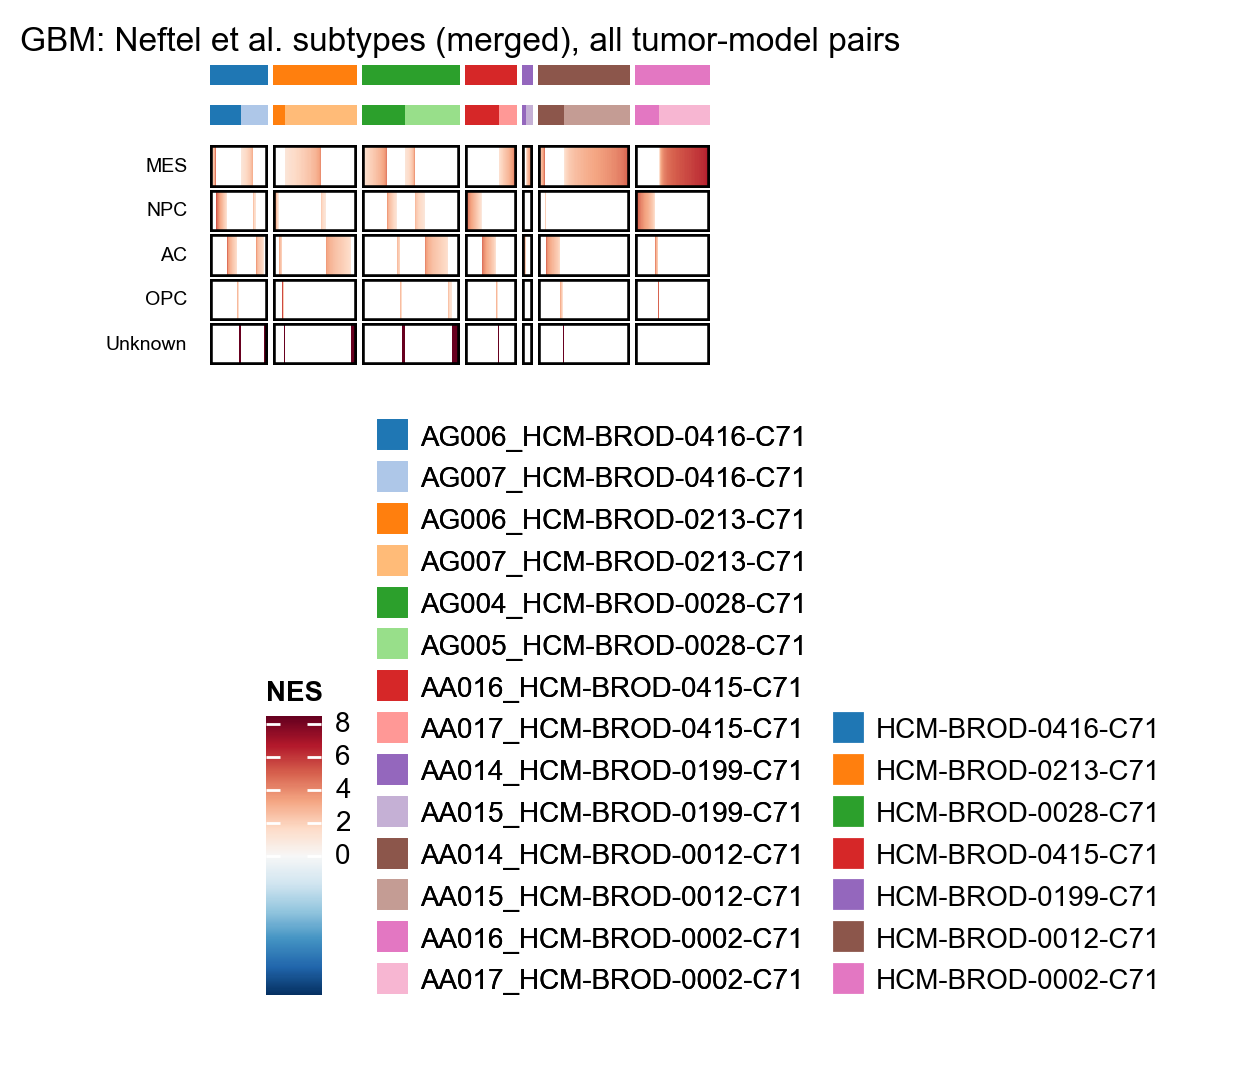

In [13]:
# plotting parameters 
title = f"{cohort}: Neftel et al. subtypes (merged), all tumor-model pairs"        
figsize = (2.5, 1.1)  # Squeezed x-axis with more height for y-axis labels

tab20 = plt.get_cmap("tab20")

# Prepare data for heatmap
exp = Suva_enr_nn_binary[:,sorted_pathways].X.T
unknown_values = Suva_enr_nn_binary.obs["Unknown"].values.reshape(-1,1).T
exp = np.vstack([exp, unknown_values])

# How to displayed the heatmap, i.e. whether with binary values or continuous values 
if binary_output:
    m = ma.Heatmap(exp, cmap="Blues", vmin=0, vmax=1, height=figsize[1], width=figsize[0], rasterized=True)  
else:
    m = ma.Heatmap(exp, cmap="RdBu_r", vmin=-0.01, center=0, vmax=range_max, height=figsize[1], width=figsize[0], label="NES", rasterized=True)
    sorted_pathways = sorted_pathways + ["Unknown"]
    
# Column grouping
ordering_samples = list(Suva_enr_nn_binary.obs["Sample ID snRNAseq"].unique())
ordering_case_types = list(Suva_enr_nn_binary.obs["Case ID"].unique())
m.group_cols(Suva_enr_nn_binary.obs['Case ID'].values, order=ordering_case_types)
m.group_rows(sorted_pathways, order=sorted_pathways)

# Plotters
color_map = {cat: tab20(i) for i, cat in enumerate(ordering_samples)}
colormap_case = {cat: tab20(i*2) for i, cat in enumerate(ordering_case_types)}
colors = mp.Colors(list(Suva_enr_nn_binary.obs['Sample ID snRNAseq']), palette=color_map)
colors_case = mp.Colors(list(Suva_enr_nn_binary.obs['Case ID']), palette=colormap_case)
subtypes = mp.Labels(sorted_pathways)

# Add annotations to heatmap
m.add_top(colors, size=0.1, pad=0.1)
m.add_top(colors_case, size=0.1, pad=0.1)
m.add_left(subtypes, pad=0.1)

# Legend and title
m.add_legends(side="bottom")
m.add_title(title)

# Render the heatmap
m.render()

# Ensure hax is a list of axes
hax = m.get_main_ax()
if not isinstance(hax, list):
    hax = [hax]

# Add rectangles around each section
for ax in hax:
    if ax:
        border = Rectangle((0, 0), 1, 1, fill=False, lw=2, transform=ax.transAxes)
        ax.add_artist(border)


**Figure 5c** - display barplots with cellular populations

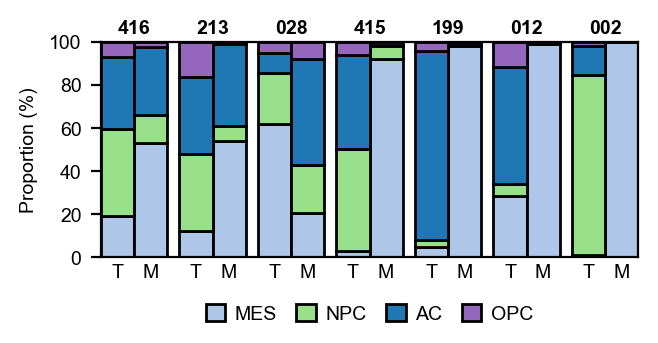

In [ ]:
# Choose columns to plot
col_assignment = "NaRnEA_tumor_centroid"
if include_unknown_barplots == True:
    sorted_pathways = ['MES', 'NPC', 'AC', 'OPC', 'Unknown'] # each attribute to plot in the radar chart
    GBM_subtypes_colormap = {
        'MES': '#AEC7E8',
        'AC': '#1F77B4',
        'NPC': '#98DF8A',
        'OPC': '#9467BD'
    }
elif include_unknown_barplots == False:
    sorted_pathways = ['MES', 'NPC', 'AC', 'OPC'] # each attribute to plot in the radar chart
    GBM_subtypes_colormap = {
        'MES': '#AEC7E8',
        'AC': '#1F77B4',
        'NPC': '#98DF8A',
        'OPC': '#9467BD',
        'Unknown': '#8C564B'
    }
num_vars = len(sorted_pathways)

# Prepare the dataframe to plot as a barplot
df_radar_all = pd.DataFrame()
n_cells_all = pd.DataFrame()
for sample in samples:
    df_radar = pd.DataFrame(Suva_enr_nn_states.obs.loc[Suva_enr_nn_states.obs["Sample ID snRNAseq"] == sample, col_assignment].value_counts()).T
    if include_unknown_barplots == False:
        df_radar = df_radar.drop(columns="Unknown")
    df_radar = df_radar.reindex(columns=sorted_pathways, fill_value=0)
    n_cells = pd.DataFrame({"sample": [sample], "n_cells": [df_radar.sum().sum()]})
    #df_radar = df_radar[sorted_pathways]
    df_radar.index = [sample]
    df_radar = df_radar.div(df_radar.sum(axis=1), axis=0) * 100
    df_radar_all = pd.concat([df_radar_all, df_radar])
    n_cells_all = pd.concat([n_cells_all, n_cells])

# Simplify identifiers from full sample ID
group_labels = list(dict.fromkeys(simplify_identifier(idx) for idx in df_radar_all.index)) # group labels for plotting


# Generate barplots
plot_grouped_stacked_bar(
    df_radar_all, 
    figsize=(3.3, 1.85), 
    title="", 
    colormap=GBM_subtypes_colormap, 
    group_labels=group_labels, 
    group_gap=0.15, 
    tick_label_size=7,  # Adjust tick label size
    title_size=7,       # Adjust title size
    legend_size=7,      # Adjust legend size
    axis_label_size=7,  # Adjust axis label size
    n_cells_dataframe = n_cells_all, 
)


Delete variables to reduce memory usage

In [15]:
del adata_all, df_radar_all
gc.collect()

7457